# Hybrid metaheurisique : Clark and wright / Tabu search 

In [98]:
import numpy as np
from scipy.spatial import distance_matrix
from collections import deque
from functools import lru_cache
from functions import get_vrptw_instance
from functions import show 
import random 
import statistics
import copy  
from ipywidgets import IntProgress
from IPython.display import display


In [118]:

# Instances
instance_name = "M/M-n101-k10.vrp"
data_set, data_set_solution = get_vrptw_instance(instance_name)

# DataSET
capacity = data_set['capacity']
coords = data_set['node_coord']
demand = data_set['demand']
NB_CLIENT=len(coords)-1


# Distance between two points
points = np.array(coords)
DISTANCE = distance_matrix(points, points)

#

def total_travel_distance(solution):
    dist_tot = 0
    for route in solution:
        full_route = [0] + route + [0]
        for client in range(len(full_route)-1):
            origin = full_route[client]
            destination = full_route[client + 1]
            dist_tot += DISTANCE[origin, destination]

    return dist_tot



# dataSetSolution
BEST_SOLUTION = data_set_solution['routes']
BEST_SOLUTION_VALUE= total_travel_distance(BEST_SOLUTION)

#variable 
#TABU
ITER_MAX = 200          # Plus d'itérations pour mieux explorer
NB_NEIGHBOR = 100       # Plus de voisins pour plus de diversité
TAILLE_LISTE_TABOU = 100 # Liste tabou plus courte pour ne pas trop restreindre

#Test
NB_TEST = 10



## First initialisation with C/W 

In [100]:
def clark_and_wright():
    """
    Create a basic solution by combining the most economical client pair each other
    """
    # variable
    distance =  data_set['edge_weight']

    solution = [np.array([i]) for i in range(1, NB_CLIENT + 1)]

    # economic matrix cost between i and j matric. (Sij)
    # Sij = cost(i, 0) + cost(0, j) - cost(i, j)
    economic_matrix = distance[:, 0][:, np.newaxis] + distance[0, :] - distance

    # sort
    i_indice, j_indice = np.triu_indices_from(economic_matrix, k=1)
    values = economic_matrix[i_indice, j_indice]
    arg_sort = np.argsort(values)[::-1]

    sorted_Sij = values[arg_sort]
    i_sorted_idx = i_indice[arg_sort]
    j_sorted_idx = j_indice[arg_sort]

    for k in range(len(sorted_Sij)):
        client_i = i_sorted_idx[k]
        client_j = j_sorted_idx[k]

        route_client_i = None
        route_client_j = None
        idx_i = None
        idx_j = None
        
        for idx, route in enumerate(solution):
            if client_i in route:
                route_client_i = route
                idx_i = idx
            if client_j in route:
                route_client_j = route
                idx_j = idx

        if idx_i is None or idx_j is None or idx_i == idx_j:
            continue
        
        is_i_start = (client_i == route_client_i[0])
        is_i_end = (client_i == route_client_i[-1])
        is_j_start = (client_j == route_client_j[0])
        is_j_end = (client_j == route_client_j[-1])


        if not ((is_i_start or is_i_end) or (is_j_start or is_j_end)):
            continue
    
        new_route = None

        if is_i_end and is_j_start:
            potential_new_route = np.concatenate([route_client_i, route_client_j])
            if is_route_feasable(potential_new_route):
                new_route = potential_new_route

        elif is_j_end and is_i_start:
            potential_new_route = np.concatenate([route_client_j, route_client_i])
            if is_route_feasable(potential_new_route):
                new_route = potential_new_route

        elif is_i_start and is_j_start:
            potential_new_route = np.concatenate([route_client_i[::-1], route_client_j])
            if is_route_feasable(potential_new_route):
                new_route = potential_new_route

        elif is_i_end and is_j_end:
            potential_new_route = np.concatenate([route_client_i, route_client_j[::-1]])
            if is_route_feasable(potential_new_route):
                new_route = potential_new_route

        if new_route is not None:
            if idx_j > idx_i:
                solution[idx_i] = new_route
                del solution[idx_j]
            else:
                solution[idx_j] = new_route
                del solution[idx_i]
            

    return [route.tolist() for route in solution]

def is_route_feasable(route):
    if sum(demand[k] for k in route) <= capacity:
        return True


## Tabou search 

In [101]:
import matplotlib.pyplot as plt

def split(giant_tour):
    """
    Split the giant tour into multiple feasible routes.
    Args:
        giant_tour (list[int]): A giant tour representing a full permutation
        of all clients.

    Returns:
        sol (list[list[int]]): A list of routes, where each route is a list
        of clients assigned to the same truck, respecting capacity constraints.
    """
    route=[]
    sol =[]
    cost =0 
    for client in giant_tour:
        if cost + demand[client] <= capacity:
            route.append(client)
            cost += demand[client]
        else :
            sol.append(route)
            cost = demand[client]
            route = [client] 
    sol.append(route)

    return sol 

def merge(solution):
    """
    Merge a solution into a giant list
    Args:
        solution(list[list[int]]):
            A solution of the vrp.
            With k lists of c int elements.
            With k number of routes(trucks) and c number of client in the route.
    Returns:
        giant_tour(list[int]): Merge of the all routes into a giant list.
    """
    giant_tour = []
    for route in solution:
        for city in route:
            if city != 0:
                giant_tour.append(city)
    return giant_tour


def random_solution():
    """
    Generate a random VRP solution.
    Args:
        None

    Returns:
        solution (list[list[int]]): A feasible solution composed of several routes,
        obtained by generating a random giant tour and splitting it into routes
        respecting the truck capacity constraints.
    """

    giant_tour = random.sample(range(NB_CLIENT + 1), k=NB_CLIENT + 1)
    solution = split(giant_tour)
    return solution


In [102]:
def neighborhood(solution, nb_neighbors, nb_swaps_per_neighbor):
    """
    Find nb_neighbors solution's neighbor
    Args:
        solution(list[list[int]]):
            A solution of the vrp.
            With k lists of c int elements.
            With k number of routes(trucks) and c number of client in the route.
        nb_neighbors(int):
            number of neighbors that we want to have for the solution
        nb_swaps_per_neighbor(int):
            number of swap per neighbor.
            if nb_swaps_per_neighbor = 1 we swap 2 values between them
            if nb_swaps_per_neighbor = 2 we swap two time 2 differente values between them
    Returns:
        neighbors(list[solution]):
            list of nb_neighbors solution's neighbor
    """
    neighbors = []

    giant_tour = merge(solution)
    size_giant_tour = len(giant_tour)

    i, j = random.sample(range(size_giant_tour), 2)
    for _ in range(nb_neighbors):
        neighbor_giant_tour = giant_tour.copy()
        for _ in range(nb_swaps_per_neighbor):
            i, j = random.sample(range(size_giant_tour), 2)
            neighbor_giant_tour[i], neighbor_giant_tour[j] = neighbor_giant_tour[j], neighbor_giant_tour[i]
        neighbors.append(split(neighbor_giant_tour))
    return neighbors



In [103]:




def tabu_search(initial_solution):
    """
    1. We start from an element of our search set that we state current element
    2. We consider the neighbourhood of the current element, we choose the best of them
    as a new current element, among those missing from the tabu list, and we add it
    to the tabu list
    3. We run a loop until the output condition is reached.
    """
    nb_iter = 0
    tabu_list = deque(maxlen=TAILLE_LISTE_TABOU)

    # variables solutions for finding the neighbour optimal not tabu
    current_solution = initial_solution
    best = initial_solution
    best_global = initial_solution

    # variables values for finding neighbour optimal not tabu
    value_best = total_travel_distance(initial_solution)
    value_best_global = value_best


    while (nb_iter < ITER_MAX):
        value_best = float('inf')
        # we go through all the neighbours of the current solution
        for neighbor in neighborhood(current_solution,NB_NEIGHBOR,1):
            neighbor_tuple =[ route for route in neighbor]
            if total_travel_distance(neighbor_tuple) < value_best and neighbor_tuple not in tabu_list:
                value_best = total_travel_distance(neighbor_tuple)
                best = neighbor_tuple

        # we update the best solution encountered since the beginning
        if value_best < value_best_global:
            best_global = best
            value_best_global = value_best
            nb_iter = 0
        else:
            nb_iter += 1

        # we go to the best non-tabu neighbour found
        current_solution = best

        # we update the tabu list
        tabu_list.append(current_solution)

    # ensure the returned solution has the original expected type: list of lists
    return best_global


## Test + affichage

1860.9424980238068
[[21, 7, 10, 63, 1], [71, 34, 2, 37, 8, 78, 30, 6, 24], [51, 77, 3, 53, 66, 67, 38, 36], [58, 32, 4, 22, 45, 50, 76, 70], [64, 17, 31, 27, 59, 5, 23, 62], [72, 54, 9, 55, 15, 41, 25, 75, 20, 46], [11, 52, 28, 79, 18, 48, 14], [12, 44, 29, 60, 39, 74, 13], [33, 47, 56, 69, 65, 35, 26, 19, 57, 61, 16, 43, 68], [40, 42, 73, 49]]
1860.9424980238068
1766.4999433704209
5.346309520576199


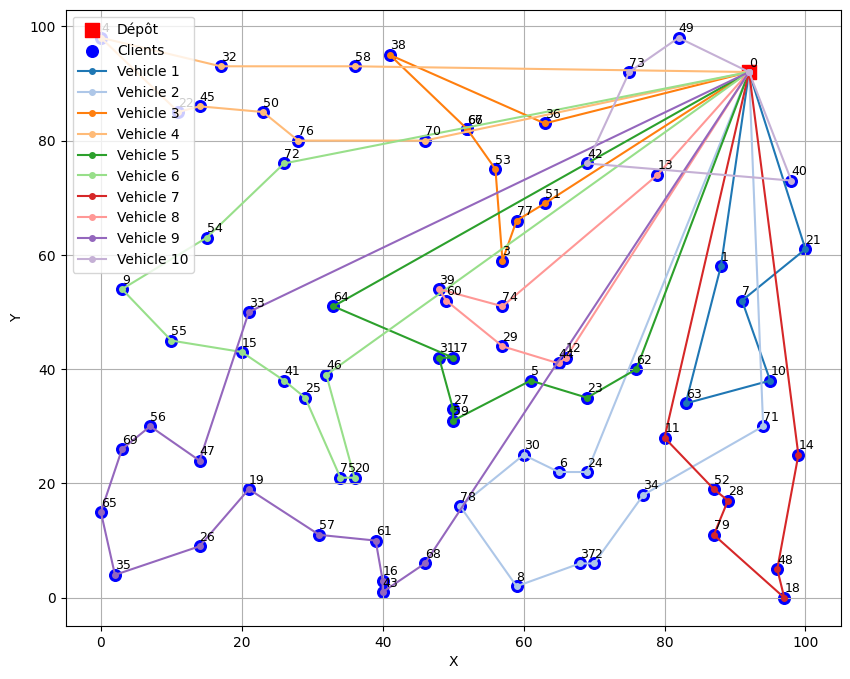

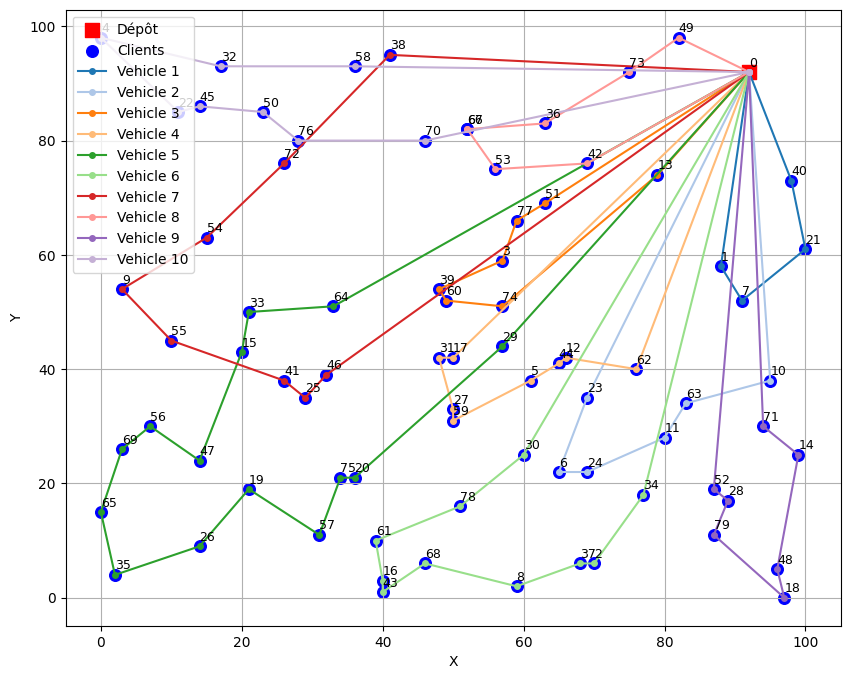

In [111]:

C=clark_and_wright()
print(total_travel_distance(C))
best=tabu_search(C)
print(best)
print(total_travel_distance(best))
print(BEST_SOLUTION_VALUE)
gap =(total_travel_distance(C)-BEST_SOLUTION_VALUE) /BEST_SOLUTION_VALUE*100 
print(gap)
show(C, data_set)
show(BEST_SOLUTION,data_set)

In [112]:
def two_opt_route(route):
    """Applique l'opérateur 2-opt sur une route individuelle.
    Retourne la meilleure route trouvée après amélioration locale.
    """
    n = len(route)
    if n <= 2:
        return route

    improved = True
    best_route = route.copy()

    # On itère jusqu'à plus d'amélioration
    while improved:
        improved = False
        for i in range(0, n - 2):
            for j in range(i + 2, n):
                # construire la nouvelle route en inversant le segment (i+1..j)
                new_route = best_route[:i+1] + best_route[i+1:j+1][::-1] + best_route[j+1:]
                # évaluer la nouvelle route (en incluant le dépôt)
                if total_travel_distance([new_route]) < total_travel_distance([best_route]):
                    best_route = new_route
                    improved = True
        # si on a trouvé une amélioration, la boucle recommence
    return best_route


def apply_two_opt(solution):
    """Applique 2-opt sur chaque route de la solution.
    Retourne une nouvelle solution améliorée.
    """
    improved_solution = []
    for route in solution:
        if len(route) > 2:
            improved_solution.append(two_opt_route(route))
        else:
            improved_solution.append(route)
    return improved_solution


In [113]:
def tabu_search_with_2opt(initial_solution):
    """Recherche tabou qui applique 2-opt aux voisins avant évaluation."""
    nb_iter = 0
    tabu_list = deque(maxlen=TAILLE_LISTE_TABOU)

    # améliorer la solution initiale
    current_solution = apply_two_opt(initial_solution)
    best_global = current_solution
    value_best_global = total_travel_distance(best_global)

    while nb_iter < ITER_MAX:
        best_neighbor = None
        best_value = float('inf')

        # parcourir le voisinage, appliquer 2-opt sur chaque voisin
        for neighbor in neighborhood(current_solution, NB_NEIGHBOR, 1):
            improved = apply_two_opt(neighbor)
            val = total_travel_distance(improved)

            if val < best_value and improved not in tabu_list:
                best_neighbor = improved
                best_value = val

        # si aucun voisin valide, diversification (perturbation aléatoire)
        if best_neighbor is None:
            current_solution = random_solution()
            current_solution = apply_two_opt(current_solution)
            nb_iter += 1
            continue

        # mise à jour du meilleur global
        if best_value < value_best_global:
            best_global = best_neighbor
            value_best_global = best_value
            nb_iter = 0
        else:
            nb_iter += 1

        current_solution = best_neighbor
        tabu_list.append(current_solution)

    return best_global


In [114]:
def perturb_solution(solution, swap_fraction=0.25):
    """Applique une forte perturbation (swaps + inversion de segment) sur une solution."""
    giant = merge(solution)
    n = len(giant)
    if n <= 2:
        return solution

    num_swaps = max(1, int(n * swap_fraction))
    for _ in range(num_swaps):
        i, j = random.sample(range(n), 2)
        giant[i], giant[j] = giant[j], giant[i]

    # inverser un segment aléatoire
    if n > 3 and random.random() < 0.5:
        a = random.randint(0, n-2)
        b = random.randint(a+1, n-1)
        giant[a:b+1] = giant[a:b+1][::-1]

    return split(giant)


def hybrid_tabu_search(initial_solution):
    """Tabu search hybride alternant 2-opt, swaps et perturbations."""
    nb_iter = 0
    tabu_list = deque(maxlen=TAILLE_LISTE_TABOU)

    current_solution = apply_two_opt(initial_solution)
    best_global = current_solution
    value_best_global = total_travel_distance(best_global)

    iterations_sans_amelioration = 0
    phase = "diversification"

    while nb_iter < ITER_MAX:
        if phase == "diversification":
            neighbors = neighborhood(current_solution, NB_NEIGHBOR, 2)
        else:
            neighbors = neighborhood(current_solution, NB_NEIGHBOR, 1)

        best_neighbor = None
        best_value = float('inf')

        for neighbor in neighbors:
            improved = apply_two_opt(neighbor)
            val = total_travel_distance(improved)
            if val < best_value and improved not in tabu_list:
                best_neighbor = improved
                best_value = val

        if best_neighbor is None:
            # forte perturbation
            current_solution = perturb_solution(current_solution)
            iterations_sans_amelioration += 1
            nb_iter += 1
            continue

        if best_value < value_best_global:
            best_global = best_neighbor
            value_best_global = best_value
            iterations_sans_amelioration = 0
            nb_iter = 0
        else:
            iterations_sans_amelioration += 1
            nb_iter += 1

        current_solution = best_neighbor
        tabu_list.append(current_solution)

        # oscillation entre diversification et intensification
        if iterations_sans_amelioration >= max(5, ITER_MAX // 10):
            if phase == "diversification":
                phase = "intensification"
            else:
                phase = "diversification"
            iterations_sans_amelioration = 0

    return best_global


=== Test comparatif ===
Coût initial (C&W) : 833.5085732089909
Coût après 2-opt simple : 826.0724939241123 (gain 7.44)
Coût initial (C&W) : 833.5085732089909
Coût après 2-opt simple : 826.0724939241123 (gain 7.44)
Coût Tabu+2-opt : 826.0724939241123 (gain 7.44)
Coût Tabu+2-opt : 826.0724939241123 (gain 7.44)
Coût Hybride : 826.0724939241123 (gain 7.44)
Meilleure solution connue : 819.8108473050879
Gap Tabu+2-opt : 0.76%
Gap Hybride : 0.76%
Coût Hybride : 826.0724939241123 (gain 7.44)
Meilleure solution connue : 819.8108473050879
Gap Tabu+2-opt : 0.76%
Gap Hybride : 0.76%


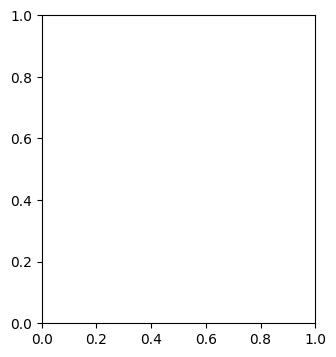

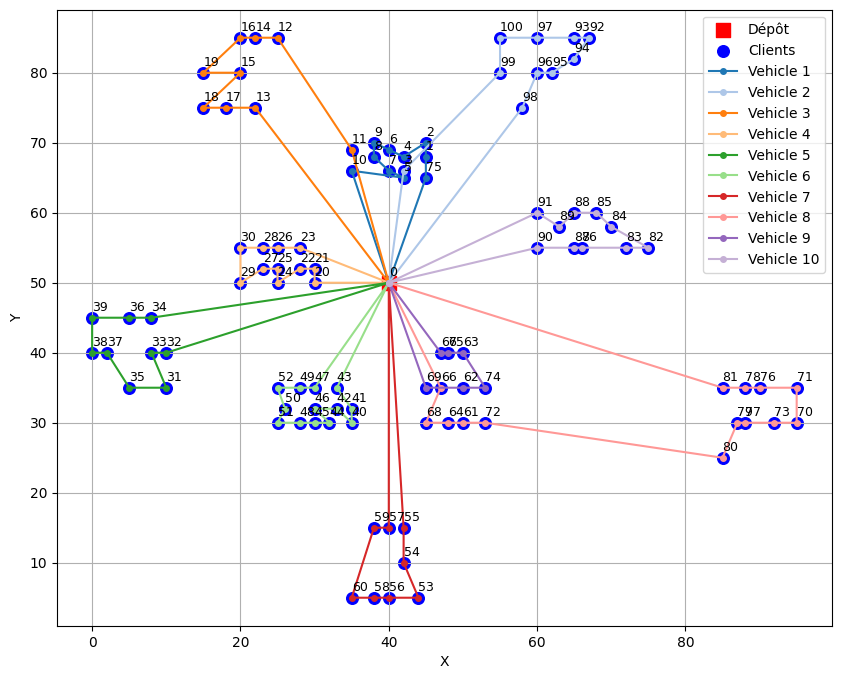

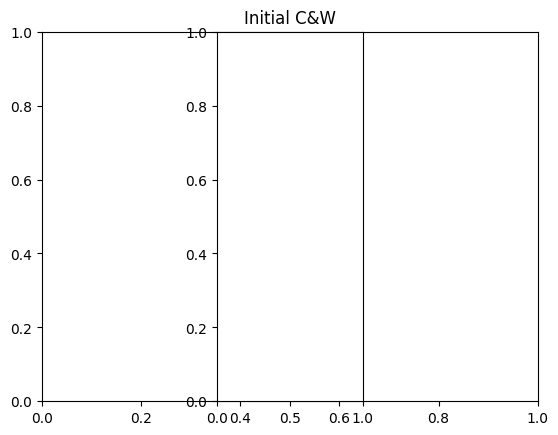

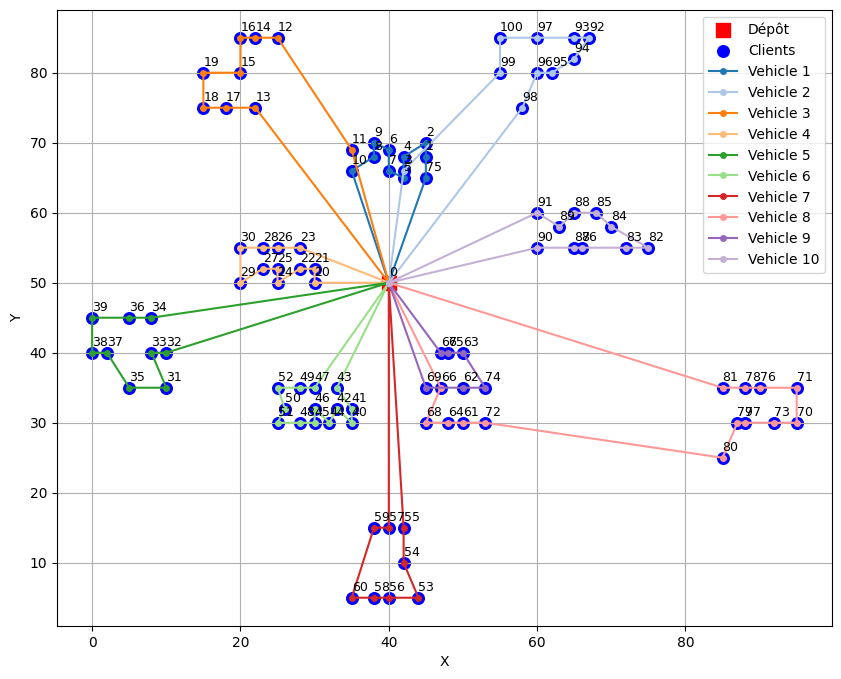

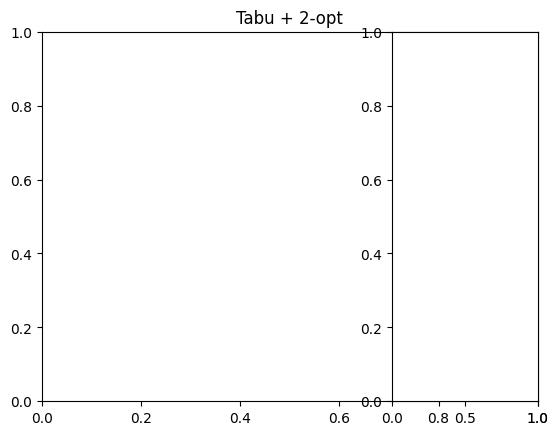

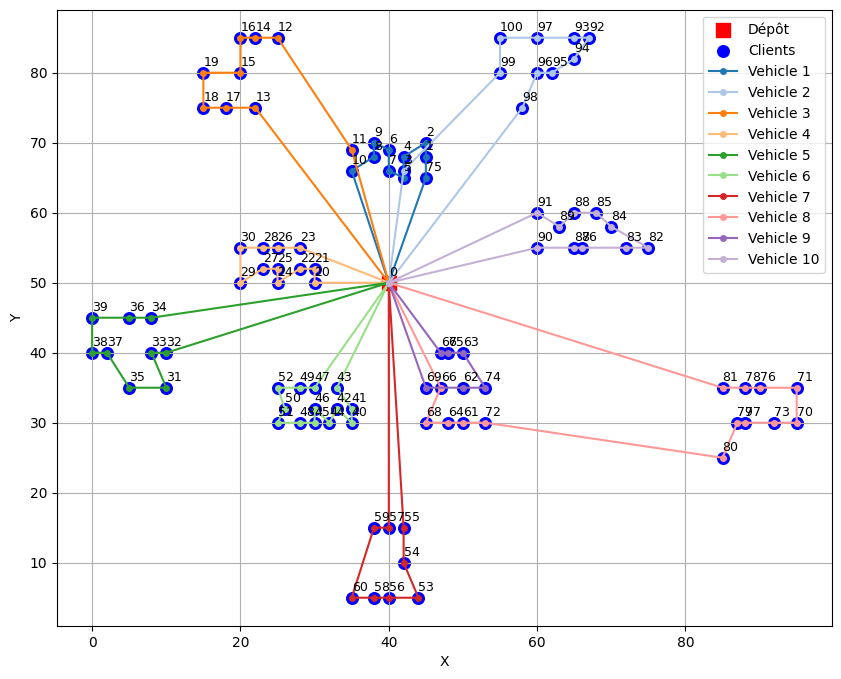

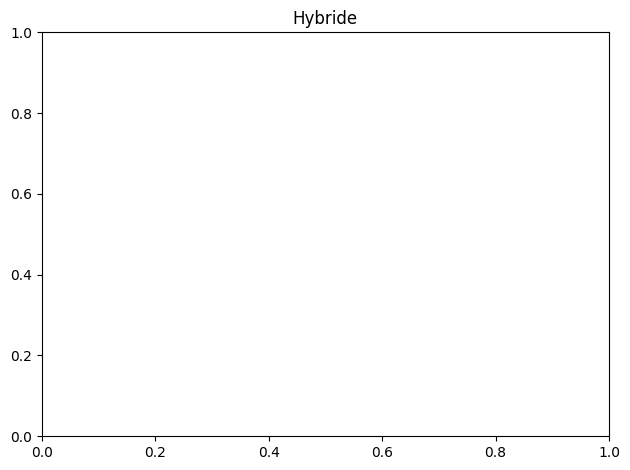


Statistiques rapides sur 5 exécutions:
Tabu+2-opt - mean: 826.0724939241123 std: 0.0 best: 826.0724939241123
Hybride     - mean: 826.0724939241123 std: 0.0 best: 826.0724939241123


C:\Users\ameli\AppData\Local\Temp\ipykernel_22724\4012663022.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([res_tabu, res_hybrid], labels=['Tabu+2-opt','Hybride'])


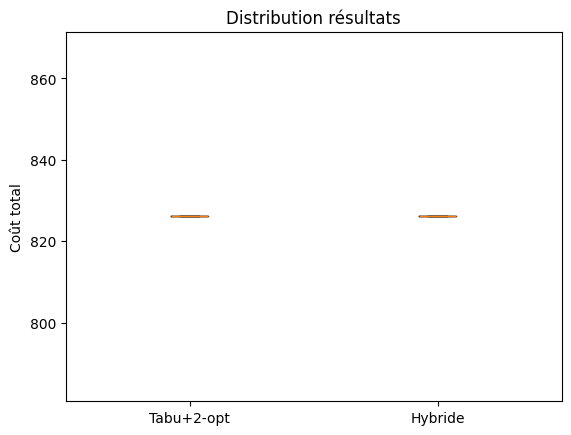

In [119]:
# Tests comparatifs des méthodes (2-opt, tabu+2-opt, hybride)
print("=== Test comparatif ===")

# solution initiale C&W
initial_sol = clark_and_wright()
initial_cost = total_travel_distance(initial_sol)
print(f"Coût initial (C&W) : {initial_cost}")

# appliquer 2-opt simple
improved_sol = apply_two_opt(initial_sol)
improved_cost = total_travel_distance(improved_sol)
print(f"Coût après 2-opt simple : {improved_cost} (gain {initial_cost - improved_cost:.2f})")

# tabu avec 2-opt
best_tabu_2opt = tabu_search_with_2opt(initial_sol)
best_tabu_2opt_cost = total_travel_distance(best_tabu_2opt)
print(f"Coût Tabu+2-opt : {best_tabu_2opt_cost} (gain {initial_cost - best_tabu_2opt_cost:.2f})")

# hybride
best_hybrid = hybrid_tabu_search(initial_sol)
best_hybrid_cost = total_travel_distance(best_hybrid)
print(f"Coût Hybride : {best_hybrid_cost} (gain {initial_cost - best_hybrid_cost:.2f})")

print(f"Meilleure solution connue : {BEST_SOLUTION_VALUE}")
print(f"Gap Tabu+2-opt : {((best_tabu_2opt_cost - BEST_SOLUTION_VALUE) / BEST_SOLUTION_VALUE) * 100:.2f}%")
print(f"Gap Hybride : {((best_hybrid_cost - BEST_SOLUTION_VALUE) / BEST_SOLUTION_VALUE) * 100:.2f}%")

# affichage sommaire
try:
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    show(initial_sol, data_set)
    plt.title('Initial C&W')

    plt.subplot(1,3,2)
    show(best_tabu_2opt, data_set)
    plt.title('Tabu + 2-opt')

    plt.subplot(1,3,3)
    show(best_hybrid, data_set)
    plt.title('Hybride')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('Affichage échoué :', e)

# test de robustesse rapide
n_tests = 5
res_tabu = []
res_hybrid = []
for i in range(n_tests):
    s = clark_and_wright()
    r1 = tabu_search_with_2opt(s)
    r2 = hybrid_tabu_search(s)
    res_tabu.append(total_travel_distance(r1))
    res_hybrid.append(total_travel_distance(r2))

print('\nStatistiques rapides sur', n_tests, 'exécutions:')
print('Tabu+2-opt - mean:', np.mean(res_tabu), 'std:', np.std(res_tabu), 'best:', min(res_tabu))
print('Hybride     - mean:', np.mean(res_hybrid), 'std:', np.std(res_hybrid), 'best:', min(res_hybrid))

plt.figure()
plt.boxplot([res_tabu, res_hybrid], labels=['Tabu+2-opt','Hybride'])
plt.ylabel('Coût total')
plt.title('Distribution résultats')
plt.show()
